# Mapping and Localization on FPv1
This script gives a demo of mapping (from reference image with known extrinsics and intrinsic) and localization (via built map). We use the data from FPv1_garden as the source.

In [ ]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import pycolmap

from hloc import (
    extract_features,
    match_features,
    visualization,
    pairs_from_retrieval,
)

In [2]:
def parse_image_list(file_path):
    image_names = []
    images_poses = []
    with open(file_path, 'r') as f:
        for items in f.readlines():
            items = items.strip().split()
            # image_name = items[0]
            image_names.append(items[0].split("/")[-1])
            pose = [float(item) for item in items[1:]]
            images_poses.append(pose)   
    return image_names, images_poses

In [3]:
query_image_list, query_image_poses = parse_image_list('datasets/garden/garden_night/query_list.txt')
database_image_list, database_image_poses = parse_image_list('datasets/garden/garden_night/ref_list.txt')

## Setup
We use FPv1_series data as sources.

In [ ]:
image_dir= Path("datasets/garden/garden_night/rgb")
outputs = Path("datasets/garden/garden_night/hloc_output")
sfm_pairs = Path("datasets/garden/garden_night/hloc_output/sfm-pairs.txt")
sfm_dir = outputs / "sfm_superpoint+lg"

retrieval_conf = extract_features.confs["megaloc"]
feature_conf = extract_features.confs["superpoint_aachen"]
matcher_conf = match_features.confs["superpoint+lightglue"]

## Find image pairs via image retrieval
We extract global descriptors with NetVLAD and find for each image the most similar ones. For smaller dataset we can instead use exhaustive matching via `hloc/pairs_from_exhaustive.py`, which would find $\frac{n(n-1)}{2}$ images pairs.

## Build SfM model using database images via image retrieval

In [5]:
retrieval_path = extract_features.main(retrieval_conf, image_dir, outputs, image_list= database_image_list)
pairs_from_retrieval.main(retrieval_path, sfm_pairs, num_matched=5, query_list= database_image_list, db_list= database_image_list)

[2026/01/06 01:11:45 hloc INFO] Extracting local features with configuration:
{'model': {'name': 'megaloc'},
 'output': 'global-feats-megaloc',
 'preprocessing': {'resize_max': 1024}}
[2026/01/06 01:11:45 hloc INFO] Skipping the extraction.
[2026/01/06 01:11:45 hloc INFO] Extracting image pairs from a retrieval database.
[2026/01/06 01:11:49 hloc INFO] Found 28610 pairs.


## Extract and match local features

In [5]:
feature_path = extract_features.main(feature_conf, image_dir, outputs, image_list= database_image_list)
match_path = match_features.main(
    matcher_conf, sfm_pairs, feature_conf["output"], outputs
)

[2026/01/06 01:30:21 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 4096, 'name': 'superpoint', 'nms_radius': 3},
 'output': 'feats-superpoint-n4096-r1024',
 'preprocessing': {'grayscale': True, 'resize_max': 1024}}


[2026/01/06 01:30:23 hloc INFO] Skipping the extraction.
[2026/01/06 01:30:23 hloc INFO] Matching local features with configuration:
{'model': {'features': 'superpoint', 'name': 'lightglue'},
 'output': 'matches-superpoint-lightglue'}
[2026/01/06 01:30:23 hloc INFO] Skipping the matching.


## 3D reconstruction
1. Generate a reference model using known extrinsics and intrinsics,
2. Triangulate a new model using the keypoints and matches with the reference model.

1. Building reference model from ground truth extrinsics and calibrated intrinsics.

In [7]:
from hloc import colmap_from_extrinsics
import pycolmap
colmap_from_extrinsics.main(
    output_dir= sfm_dir,
    image_dir= image_dir,
    poses= Path("datasets/garden/garden_night/ref_list.txt"),
    intrinsics=Path("datasets/garden/garden_night/intrinsics.txt"),
    camera_mode= pycolmap.CameraMode.SINGLE,
    format = "TUM",
    image_list= database_image_list,
)

[2026/01/06 01:11:53 hloc WARNING] The database already exists, deleting it.
[2026/01/06 01:11:53 hloc INFO] Creating an empty database...


[2026/01/06 01:11:53 hloc INFO] Importing images into the database...
[2026/01/06 01:12:38 hloc INFO] Loaded 1 cameras.
[2026/01/06 01:12:38 hloc INFO] Reading poses from datasets/garden/garden_night/ref_list.txt (Format: TUM)...
[2026/01/06 01:12:38 hloc INFO] Loaded 5722 images from TUM poses.
[2026/01/06 01:12:38 hloc INFO] Writing reference model...
[2026/01/06 01:12:38 hloc INFO] Reference model (Extrinsics+Intrinsics) saved to datasets/garden/garden_night/hloc_output/sfm_superpoint+lg
[2026/01/06 01:12:38 hloc INFO] You can now run hloc.triangulation using this directory as 'reference_model'.


2. Triangulation via built reference model

The logic is that we build images.bin and camreas.bin using extrinsics and intrinsics and leave the points3D.bin blank. The triangulation process uses the keypoints and matches as well as the images.bin and cameras.bin to generate the points3D.bin.


In [6]:
from hloc import triangulation
reference_model = Path("datasets/garden/garden_night/hloc_output/sfm_superpoint+lg")

In [8]:
model_splg = triangulation.main(sfm_dir, reference_model, image_dir, sfm_pairs, feature_path, match_path)

[2026/01/06 01:17:42 hloc WARNING] The database already exists, deleting it.
[2026/01/06 01:17:42 hloc INFO] Importing features into the database...
100%|██████████| 5722/5722 [00:01<00:00, 3653.82it/s]
[2026/01/06 01:17:44 hloc INFO] Importing matches into the database...
100%|██████████| 28610/28610 [00:06<00:00, 4593.86it/s]
[2026/01/06 01:17:50 hloc INFO] Performing geometric verification of the matches...
100%|██████████| 5722/5722 [00:48<00:00, 117.29it/s]
[2026/01/06 01:18:39 hloc INFO] mean/med/min/max valid matches 81.14/94.40/0.00/100.00%.
[2026/01/06 01:18:39 hloc INFO] Running 3D triangulation...
I20260106 01:18:39.551480 140547168297344 incremental_pipeline.cc:264] Loading database
I20260106 01:18:39.552084 140547168297344 database_cache.cc:67] Loading rigs...
I20260106 01:18:39.552092 140547168297344 database_cache.cc:77]  0 in 0.000s
I20260106 01:18:39.552096 140547168297344 database_cache.cc:85] Loading cameras...
I20260106 01:18:39.552103 140547168297344 database_cache

## Visualization
We visualize some of the registered images, and color their keypoint by visibility, track length, or triangulated depth.

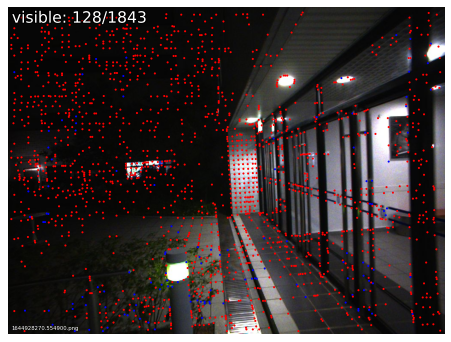

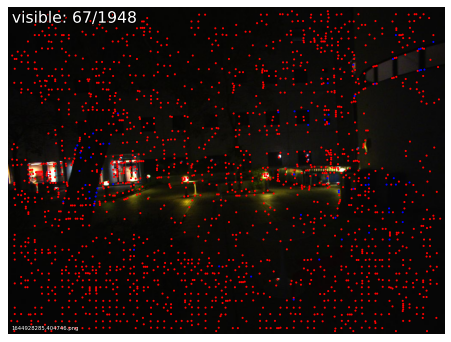

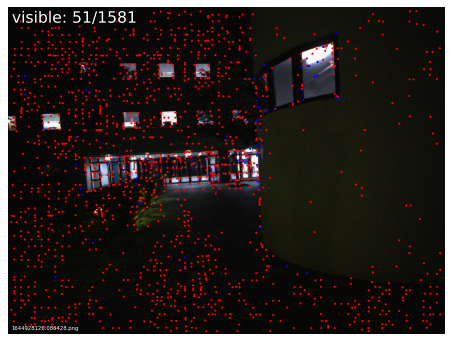

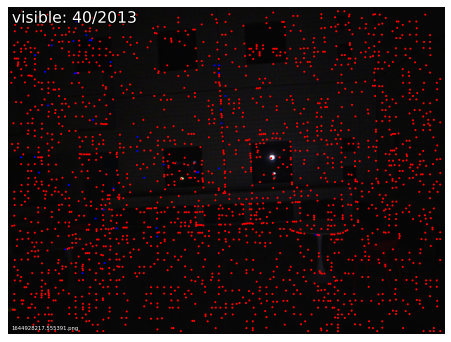

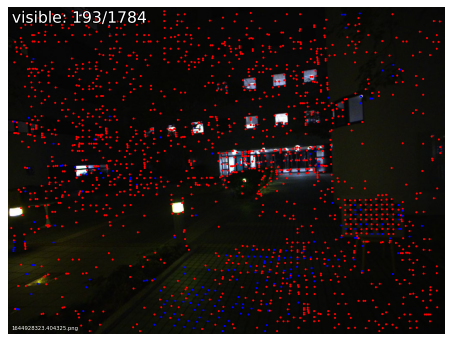

In [ ]:
model_splg = pycolmap.Reconstruction(sfm_dir)
visualization.visualize_sfm_2d(model_splg, image_dir=Path("datasets/garden/garden_night/rgb"), color_by="visibility", n=5)

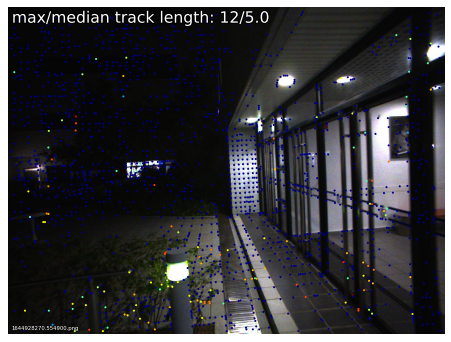

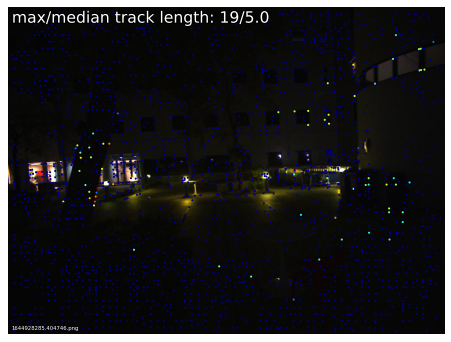

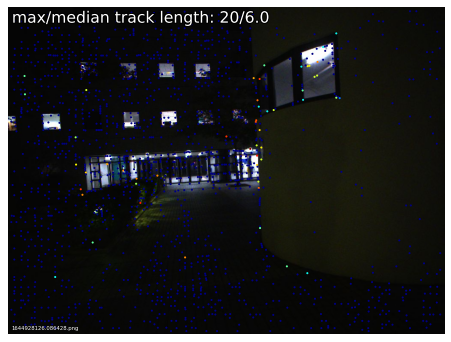

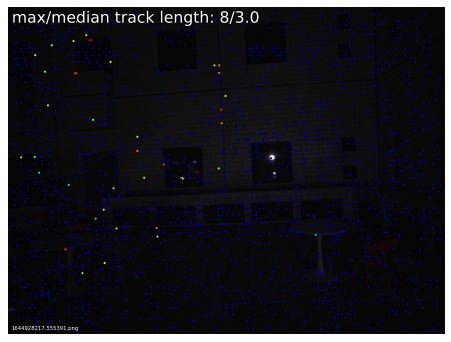

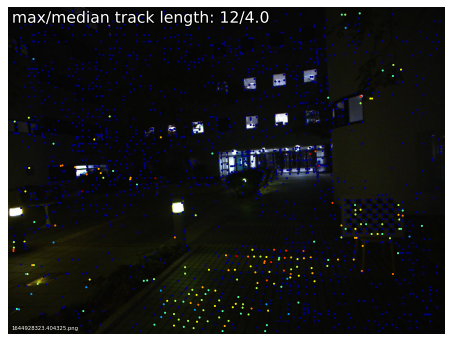

In [10]:
visualization.visualize_sfm_2d(model_splg, image_dir=Path("datasets/garden/garden_night/rgb"), color_by="track_length", n=5)

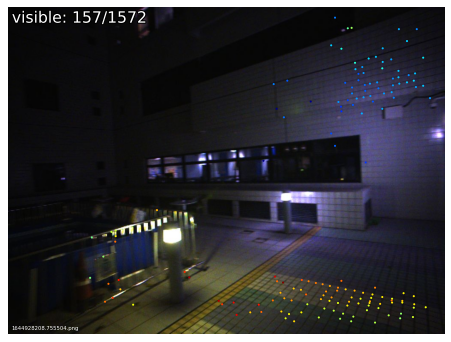

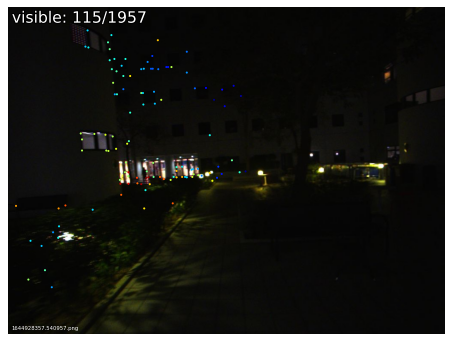

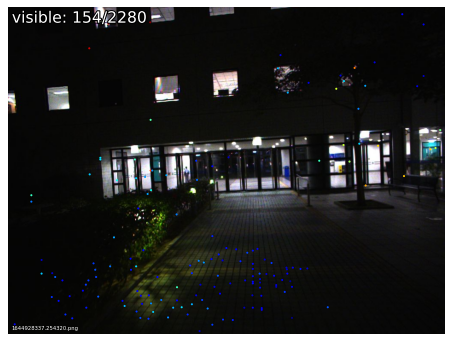

In [11]:
visualization.visualize_sfm_2d(model_splg, image_dir=Path("datasets/garden/garden_night/rgb"), color_by="depth", n=3, seed=3)

## Localization
Now it is time to perform localization.
1. First, we find query and database image pairs using image retrieval
2. Then we match these pairs
3. Localize using pnp

### Retrieve Image pairs

In [13]:
retrieval_path = extract_features.main(retrieval_conf, image_dir, outputs, image_list= query_image_list)
loc_pairs = Path("datasets/garden/garden_night/hloc_output/loc-pairs.txt")
pairs_from_retrieval.main(retrieval_path, loc_pairs, num_matched= 20, query_list=query_image_list, db_list= database_image_list)

[2026/01/06 01:32:25 hloc INFO] Extracting local features with configuration:
{'model': {'name': 'megaloc'},
 'output': 'global-feats-megaloc',
 'preprocessing': {'resize_max': 1024}}


[2026/01/06 01:32:25 hloc INFO] Skipping the extraction.
[2026/01/06 01:32:25 hloc INFO] Extracting image pairs from a retrieval database.
[2026/01/06 01:32:27 hloc INFO] Found 2520 pairs.


### Match the query images

In [14]:
feature_path = extract_features.main(feature_conf, image_dir, outputs, image_list= query_image_list)
match_path = match_features.main(
    matcher_conf, loc_pairs, feature_conf["output"], outputs
)

[2026/01/06 01:32:46 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 4096, 'name': 'superpoint', 'nms_radius': 3},
 'output': 'feats-superpoint-n4096-r1024',
 'preprocessing': {'grayscale': True, 'resize_max': 1024}}


Loaded SuperPoint model


100%|██████████| 126/126 [00:01<00:00, 79.70it/s]
[2026/01/06 01:32:49 hloc INFO] Finished exporting features.
[2026/01/06 01:32:49 hloc INFO] Matching local features with configuration:
{'model': {'features': 'superpoint', 'name': 'lightglue'},
 'output': 'matches-superpoint-lightglue'}
100%|██████████| 2520/2520 [00:30<00:00, 81.66it/s]
[2026/01/06 01:33:20 hloc INFO] Finished exporting matches.


Generate query image lists with intrinsics

In [15]:
queries_with_intrinsics = Path("datasets/garden/garden_night/queries_with_intrinsics.txt")
with open(queries_with_intrinsics, "w") as f:
    for query_name in query_image_list:
        f.write(f"{query_name} PINHOLE 1024 768 605.128601 604.97406 520.45343 393.878479\n")

In [16]:
from hloc import localize_sfm
from hloc import logger
import logging
logger.setLevel(logging.INFO)

for handler in logger.handlers:
    handler.setLevel(logging.INFO)

results = outputs / "superpoint+lg_megaloc20.txt"
localize_sfm.main(
    model_splg,
    queries_with_intrinsics,
    loc_pairs,
    feature_path,
    match_path,
    results,
    covisibility_clustering=False
)

[2026/01/06 01:33:55 hloc.utils.parsers INFO] Imported 126 images from queries_with_intrinsics.txt


[2026/01/06 01:33:55 hloc INFO] Reading the 3D model...
[2026/01/06 01:33:55 hloc INFO] Starting localization...
100%|██████████| 126/126 [00:04<00:00, 29.47it/s]
[2026/01/06 01:33:59 hloc INFO] Localized 126 / 126 images.
[2026/01/06 01:33:59 hloc INFO] Writing poses to datasets/garden/garden_night/hloc_output/superpoint+lg_megaloc20.txt...
[2026/01/06 01:33:59 hloc INFO] Writing logs to datasets/garden/garden_night/hloc_output/superpoint+lg_megaloc20.txt_logs.pkl...
[2026/01/06 01:33:59 hloc INFO] Done!


## Visualize the localization

In [70]:
visualization.visualize_loc(
    results, Path("datasets/garden/garden_day/rgb"), model_splg, n=1, top_k_db=1, seed=2)

KeyError: 'inliers'

## Evaluation
We evaluate as the absolute pose estimation procedure evalute the rotation and translation under thresholds: (0.25, 2), (0.5, 5), (5, 10)

In [19]:
from hloc.colmap_from_extrinsics import convert_from_tum_to_colmap
import numpy as np

# query_image_list = Path("datasets/garden/garden_night/query_list.txt")
# query_image_list_with_extrinsics = Path("datasets/garden/garden_night/queries_with_extrinsics.txt")

# with open(query_image_list, 'r') as fin:
#     fin_lines = fin.readlines()
# with open(query_image_list_with_extrinsics, "w") as fout:
#     for data in fin_lines:
#         items = data.strip().split(" ")
#         name = items[0].split("/")[-1]
#         tx, ty, tz = float(items[1]), float(items[2]), float(items[3])
#         qx, qy, qz, qw = float(items[4]), float(items[5]), float(items[6]), float(items[7])
#         qvec_tum_wfirst = np.array([qw, qx, qy, qz])
#         tvec_tum = np.array([tx, ty, tz])
#         # Convert C2W (TUM) -> W2C (COLMAP)
#         qvec_colmap, tvec_colmap = convert_from_tum_to_colmap(qvec_tum_wfirst, tvec_tum)
#         fout.write(f"{name} {qvec_colmap[0]} {qvec_colmap[1]} {qvec_colmap[2]} {qvec_colmap[3]} {tvec_colmap[0]} {tvec_colmap[1]} {tvec_colmap[2]}\n")

In [20]:
def quaternion_to_rotation_matrix(qvec):
    qvec = qvec / np.linalg.norm(qvec)
    w, x, y, z = qvec
    R = np.array(
        [
            [1 - 2 * y * y - 2 * z * z, 2 * x * y - 2 * z * w, 2 * x * z + 2 * y * w],
            [2 * x * y + 2 * z * w, 1 - 2 * x * x - 2 * z * z, 2 * y * z - 2 * x * w],
            [2 * x * z - 2 * y * w, 2 * y * z + 2 * x * w, 1 - 2 * x * x - 2 * y * y],
        ]
    )
    return R

def load_poses(path):
    """
    Loads poses from a text file.
    Format: name qw qx qy qz tx ty tz
    """
    poses = {}
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            
            data = line.split()
            name = data[0]
            # HLoc/COLMAP format is [w, x, y, z]
            qvec = np.array(list(map(float, data[1:5])))
            tvec = np.array(list(map(float, data[5:8])))
            poses[name] = (qvec, tvec)
    return poses

def compute_pose_error(q_vec_gt, t_vec_gt, q_vec_pred, t_vec_pred):
    # errors_t = []
    # errors_R = []
    R_gt = quaternion_to_rotation_matrix(q_vec_gt)
    R_pred = quaternion_to_rotation_matrix(q_vec_pred)
    e_t = np.linalg.norm(-R_gt.T @ t_vec_gt + R_pred.T @ t_vec_pred, axis = 0)
    cos = np.clip((np.trace(np.dot(R_gt.T, R_pred))-1)/2, -1.0, 1.0)
    e_R = np.rad2deg(np.abs(np.arccos(cos)))
    return e_t, e_R

def evaluate_absolute_pose_error(gt_dir: Path, 
                                 pred_dir: Path, 
                                 thresholds = [
                (0.25, 2),  # 25cm, 2 deg
                (0.50, 5),  # 50cm, 5 deg
                (5.00, 10)  # 5m, 10 deg
        ]):
    poses_gt = load_poses(gt_dir)
    poses_pred = load_poses(pred_dir)
    common_names = set(poses_gt.keys()) & set(poses_pred.keys())
    if not common_names:
        print("Error: No common image names found between the two files.")
        return
    print(f"Evaluating {len(common_names)} common images...")
    
    errors_t = []
    errors_r = []

    for name in common_names:
        q_gt, t_gt = poses_gt[name]
        q_pred, t_pred = poses_pred[name]
        
        t_err, r_err = compute_pose_error(q_gt, t_gt, q_pred, t_pred)
        errors_t.append(t_err)
        errors_r.append(r_err)

    errors_t = np.array(errors_t)
    errors_r = np.array(errors_r)

    # --- Reporting ---
    logger.info(f"Evaluation Results ({len(common_names)} images)\n \
                Median Position Error: {np.median(errors_t):.4f} m\n \
                Median Rotation Error: {np.median(errors_r):.4f} deg")

    for d_thresh, r_thresh in thresholds:
        # Success = Position Error < d_thresh AND Rotation Error < r_thresh
        success = (errors_t < d_thresh) & (errors_r < r_thresh)
        recall = np.mean(success) * 100
        logger.info(f"Recall @ ({d_thresh:>4}m, {r_thresh:>2}°): {recall:.2f}%")    
    

In [19]:

evaluate_absolute_pose_error(gt_dir=query_image_list_with_extrinsics, pred_dir=results)

[2026/01/06 01:34:22 hloc INFO] Evaluation Results (126 images)
                 Median Position Error: 0.0830 m
                 Median Rotation Error: 0.9921 deg
[2026/01/06 01:34:22 hloc INFO] Recall @ (0.25m,  2°): 77.78%
[2026/01/06 01:34:22 hloc INFO] Recall @ ( 0.5m,  5°): 95.24%
[2026/01/06 01:34:22 hloc INFO] Recall @ ( 5.0m, 10°): 100.00%


Evaluating 126 common images...


## qNight_dbDay

In [3]:
# images = query_image_list + database_image_list
q_image_dir= Path("datasets/garden/garden_night/rgb")
db_image_dir = Path("datasets/garden/garden_day/rgb")

outputs = Path("datasets/garden/hloc_output")
loc_pairs = outputs / "loc-pairs.txt"

sfm_dir = Path("datasets/garden/garden_day/hloc_output") / "sfm_superpoint+lg"

retrieval_conf = extract_features.confs["megaloc"]
feature_conf = extract_features.confs["superpoint_aachen"]
matcher_conf = match_features.confs["superpoint+lightglue"]

In [5]:
def convert_pairs_list(file_path, output_file_path):
    query_names = []
    db_names = []
    with open(file_path, 'r') as f:
        for items in f.readlines():
            items = items.strip().split()
            # image_name = items[0]
            query_names.append(items[0].split("/")[-1])
            db_names.append(items[1].split("/")[-1])
    with open(output_file_path, 'w') as fout:
        for q_name, db_name in zip(query_names, db_names):
            fout.write(f"{q_name} {db_name}\n")
    return query_names, db_names

In [9]:
loc_pairs.parent.mkdir(parents=True, exist_ok=True)
query_names, db_names = convert_pairs_list("datasets/garden/qNight_dbDay_pairs.txt", loc_pairs)

In [10]:
queries_with_intrinsics = Path("datasets/garden/queries_with_intrinsics.txt")
with open(queries_with_intrinsics, "w") as f:
    for query_name in query_names:
        f.write(f"{query_name} PINHOLE 1024 768 605.128601 604.97406 520.45343 393.878479\n")

In [13]:
q_features = Path("datasets/garden/garden_night/hloc_output/feats-superpoint-n4096-r1024.h5")
db_features = Path("datasets/garden/garden_day/hloc_output/feats-superpoint-n4096-r1024.h5")

match_features.main(
    matcher_conf, loc_pairs, features=q_features, features_ref=db_features, matches=outputs / "matches-superpoint+lightglue-n4096-r1024.h5"
)

[2026/01/06 11:08:39 hloc INFO] Matching local features with configuration:
{'model': {'features': 'superpoint', 'name': 'lightglue'},
 'output': 'matches-superpoint-lightglue'}
100%|██████████| 126/126 [00:02<00:00, 47.66it/s]
[2026/01/06 11:08:42 hloc INFO] Finished exporting matches.


PosixPath('datasets/garden/hloc_output/matches-superpoint+lightglue-n4096-r1024.h5')

In [16]:
from hloc import localize_sfm
from hloc import logger
import pycolmap
import logging
logger.setLevel(logging.INFO)

for handler in logger.handlers:
    handler.setLevel(logging.INFO)
model_day = pycolmap.Reconstruction(sfm_dir)
results = outputs / "superpoint+lg_pairs_from_poses.txt"
localize_sfm.main(
    model_day,
    queries_with_intrinsics,
    loc_pairs,
    q_features,
    outputs / "matches-superpoint+lightglue-n4096-r1024.h5",
    results,
    covisibility_clustering=False
)

[2026/01/06 11:11:37 hloc.utils.parsers INFO] Imported 126 images from queries_with_intrinsics.txt
[2026/01/06 11:11:37 hloc INFO] Reading the 3D model...
[2026/01/06 11:11:37 hloc INFO] Starting localization...
100%|██████████| 126/126 [00:00<00:00, 272.39it/s]
[2026/01/06 11:11:37 hloc INFO] Localized 126 / 126 images.
[2026/01/06 11:11:37 hloc INFO] Writing poses to datasets/garden/hloc_output/superpoint+lg_pairs_from_poses.txt...
[2026/01/06 11:11:37 hloc INFO] Writing logs to datasets/garden/hloc_output/superpoint+lg_pairs_from_poses.txt_logs.pkl...
[2026/01/06 11:11:37 hloc INFO] Done!


In [21]:
query_image_list_with_extrinsics = Path("datasets/garden/garden_night/queries_with_extrinsics.txt")

evaluate_absolute_pose_error(gt_dir=query_image_list_with_extrinsics, pred_dir=results)

[2026/01/06 11:13:04 hloc INFO] Evaluation Results (126 images)
                 Median Position Error: 0.2272 m
                 Median Rotation Error: 3.0823 deg
[2026/01/06 11:13:04 hloc INFO] Recall @ (0.25m,  2°): 29.37%
[2026/01/06 11:13:04 hloc INFO] Recall @ ( 0.5m,  5°): 57.14%
[2026/01/06 11:13:04 hloc INFO] Recall @ ( 5.0m, 10°): 86.51%


Evaluating 126 common images...


### Now we use image retrieval to find loc-pairs

In [24]:
q_global_path = Path("datasets/garden/garden_night/hloc_output/global-feats-megaloc.h5")
db_global_path = Path("datasets/garden/garden_day/hloc_output/global-feats-megaloc-clean.h5")
loc_pairs = outputs / "loc-pairs_megaloc20.txt"
pairs_from_retrieval.main(q_global_path, loc_pairs, num_matched=20, query_list=query_names, db_descriptors=db_global_path)

[2026/01/06 11:43:11 hloc INFO] Extracting image pairs from a retrieval database.
[2026/01/06 11:43:13 hloc INFO] Found 2520 pairs.


In [23]:
import h5py
from tqdm import tqdm

def purge_rgb_from_h5(input_path, output_path):
    input_path = Path(input_path)
    output_path = Path(output_path)
    
    if not input_path.exists():
        print(f"Error: Input file {input_path} not found.")
        return

    print(f"Processing: {input_path}")
    print(f"Creating:   {output_path}")

    with h5py.File(input_path, 'r') as f_in, h5py.File(output_path, 'w') as f_out:
        # hloc stores paths as keys. 
        # '1644928123.png' -> key is '1644928123.png' (Dataset)
        # 'rgb/1645002496.png' -> key is 'rgb' (Group) -> inside is '1645002496.png'
        
        # We iterate over the top-level keys
        for key in tqdm(f_in.keys(), desc="Filtering keys"):
            
            # 1. Skip the 'rgb' group entirely
            if key == 'rgb':
                print(f"Skipping group: {key} (contains rgb/ names)")
                continue
            
            # 2. Skip any other keys that might start with 'rgb' (just in case)
            if key.startswith('rgb'):
                continue

            # 3. Copy everything else (the valid data)
            # copy_object copies the dataset/group and all its attributes/data
            f_in.copy(key, f_out)
            
    print("\nDone! Please verify the new file works with hloc.")
    print("If successful, you can rename the new file to replace the old one.")

# --- usage ---
# Replace with your actual file names
purge_rgb_from_h5('datasets/garden/garden_day/hloc_output/global-feats-megaloc.h5', 'datasets/garden/garden_day/hloc_output/global-feats-megaloc-clean.h5')

Processing: datasets/garden/garden_day/hloc_output/global-feats-megaloc.h5
Creating:   datasets/garden/garden_day/hloc_output/global-feats-megaloc-clean.h5


Filtering keys: 100%|██████████| 5753/5753 [00:00<00:00, 26629.69it/s]

Skipping group: rgb (contains rgb/ names)

Done! Please verify the new file works with hloc.
If successful, you can rename the new file to replace the old one.


In [25]:
q_features = Path("datasets/garden/garden_night/hloc_output/feats-superpoint-n4096-r1024.h5")
db_features = Path("datasets/garden/garden_day/hloc_output/feats-superpoint-n4096-r1024.h5")

match_features.main(
    matcher_conf, loc_pairs, features=q_features, features_ref=db_features, matches=outputs / "matches-superpoint+lightglue-n4096-r1024.h5"
)

[2026/01/06 11:43:40 hloc INFO] Matching local features with configuration:
{'model': {'features': 'superpoint', 'name': 'lightglue'},
 'output': 'matches-superpoint-lightglue'}
100%|██████████| 2478/2478 [00:46<00:00, 53.28it/s]
[2026/01/06 11:44:26 hloc INFO] Finished exporting matches.


PosixPath('datasets/garden/hloc_output/matches-superpoint+lightglue-n4096-r1024.h5')

In [26]:
from hloc import localize_sfm
from hloc import logger
import pycolmap
import logging
logger.setLevel(logging.INFO)

for handler in logger.handlers:
    handler.setLevel(logging.INFO)
model_day = pycolmap.Reconstruction(sfm_dir)
results = outputs / "superpoint+lg_megaloc20.txt"
localize_sfm.main(
    model_day,
    queries_with_intrinsics,
    loc_pairs,
    q_features,
    outputs / "matches-superpoint+lightglue-n4096-r1024.h5",
    results,
    covisibility_clustering=False
)

[2026/01/06 11:45:06 hloc.utils.parsers INFO] Imported 126 images from queries_with_intrinsics.txt
[2026/01/06 11:45:06 hloc INFO] Reading the 3D model...
[2026/01/06 11:45:06 hloc INFO] Starting localization...
  2%|▏         | 3/126 [00:00<00:05, 24.59it/s][2026/01/06 11:45:06 hloc WARNING] Image 1645002398.014137.png was retrieved but not in database
[2026/01/06 11:45:06 hloc WARNING] Image 1645002500.143579.png was retrieved but not in database
[2026/01/06 11:45:06 hloc WARNING] Image 1645002401.723153.png was retrieved but not in database
[2026/01/06 11:45:06 hloc WARNING] Image 1645002399.865861.png was retrieved but not in database
  7%|▋         | 9/126 [00:00<00:05, 22.78it/s][2026/01/06 11:45:06 hloc WARNING] Image 1645002408.922751.png was retrieved but not in database
[2026/01/06 11:45:06 hloc WARNING] Image 1645002410.773424.png was retrieved but not in database
 10%|▉         | 12/126 [00:00<00:06, 18.26it/s][2026/01/06 11:45:06 hloc WARNING] Image 1645002412.723372.png w

In [27]:
query_image_list_with_extrinsics = Path("datasets/garden/garden_night/queries_with_extrinsics.txt")

evaluate_absolute_pose_error(gt_dir=query_image_list_with_extrinsics, pred_dir=results)

[2026/01/06 11:45:45 hloc INFO] Evaluation Results (126 images)
                 Median Position Error: 0.4006 m
                 Median Rotation Error: 3.1243 deg
[2026/01/06 11:45:45 hloc INFO] Recall @ (0.25m,  2°): 19.84%
[2026/01/06 11:45:45 hloc INFO] Recall @ ( 0.5m,  5°): 48.41%
[2026/01/06 11:45:45 hloc INFO] Recall @ ( 5.0m, 10°): 89.68%


Evaluating 126 common images...
